# Bridge Ranking Map Visualization (A4)

This notebook visualizes the top 20 bridges by:
1. traffic rank
2. betweenness rank
3. combined rank

Map style follows the road-network plotting approach used in A3 notebook cell 4.

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [26]:
# Paths are relative to EPA133a-G14-A4/notebook/
ranking_path = Path('../experiment/round1_baseline/bridge_ranking.csv')
network_path = Path('../data/integrated_data.csv')

ranking_df = pd.read_csv(ranking_path)
network_df = pd.read_csv(network_path)

print('Ranking rows:', len(ranking_df))
print('Network rows:', len(network_df))
display(ranking_df.head(3))

Ranking rows: 737
Network rows: 4083


,bridge_id,avg_trucks_crossed,betweenness,norm_traffic,norm_betweenness,combined_score,rank_by_traffic,rank_by_betweenness,rank_by_combined
0,2000278,30341.1,0.448838,0.999654,0.909022,0.972465,18,33,1
1,2000284,30340.6,0.447889,0.999638,0.907100,0.971876,19,35,2
2,2000288,30339.3,0.447251,0.999595,0.905809,0.971459,20,36,3


In [27]:
# Prepare network components for base-map plotting
df = network_df.copy()
df['model_type'] = df['model_type'].astype(str).str.strip().str.lower()
df['id_num'] = pd.to_numeric(df['id'], errors='coerce')
df['lat'] = pd.to_numeric(df['lat'], errors='coerce')
df['lon'] = pd.to_numeric(df['lon'], errors='coerce')
df['lrp'] = df['lrp'].fillna('').astype(str).str.strip()

ranking_df['bridge_id_num'] = pd.to_numeric(ranking_df['bridge_id'], errors='coerce')

bridges = df[df['model_type'] == 'bridge'].copy()
links = df[df['model_type'] == 'link'].copy()
sourcesinks = df[df['model_type'] == 'sourcesink'].copy()
intersections = df[df['model_type'] == 'intersection'].copy()

# Keep only rows with coordinates
bridges = bridges.dropna(subset=['lat', 'lon'])
links = links.dropna(subset=['lat', 'lon'])
sourcesinks = sourcesinks.dropna(subset=['lat', 'lon'])
intersections = intersections.dropna(subset=['lat', 'lon'])

# Merge ranking metrics onto bridge geometry
bridge_geo = bridges.merge(
    ranking_df,
    left_on='id_num',
    right_on='bridge_id_num',
    how='inner'
)

print('Bridges with ranking and coordinates:', len(bridge_geo))
display(bridge_geo[['bridge_id', 'road', 'lat', 'lon', 'rank_by_traffic', 'rank_by_betweenness', 'rank_by_combined']].head(5))

Bridges with ranking and coordinates: 737


,bridge_id,road,lat,lon,rank_by_traffic,rank_by_betweenness,rank_by_combined
0,1000015,N1,23.703347,90.517305,303,727,392
1,1000025,N1,23.694361,90.537611,377,720,480
2,1000027,N1,23.692277,90.541055,379,712,478
3,1000030,N1,23.691083,90.545014,378,708,477
4,1000035,N1,23.685500,90.551278,239,457,301


In [28]:
def draw_base_network(ax, df_all):
    # Draw only road backbone lines (no background points).
    roads = df_all['road'].dropna().unique().tolist()
    for road in roads:
        rd = df_all[(df_all['road'] == road)
                    & (df_all['model_type'].isin(['link', 'bridge', 'sourcesink']))
                    & (df_all['lrp'] != '')]
        if len(rd) > 1:
            ax.plot(rd['lon'], rd['lat'], linewidth=0.6, color='grey', alpha=0.55, zorder=1)

    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.grid(True, alpha=0.25)
    ax.set_aspect('equal')


def get_top_n(df_bridge_geo, rank_col, n=20):
    return df_bridge_geo.nsmallest(n, rank_col).sort_values(rank_col).copy()

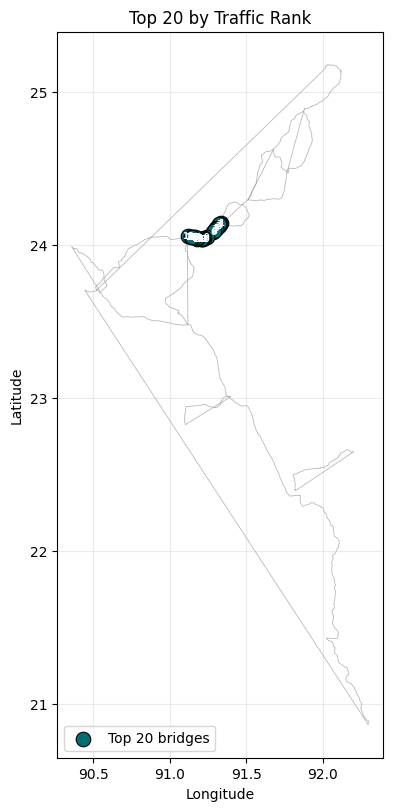

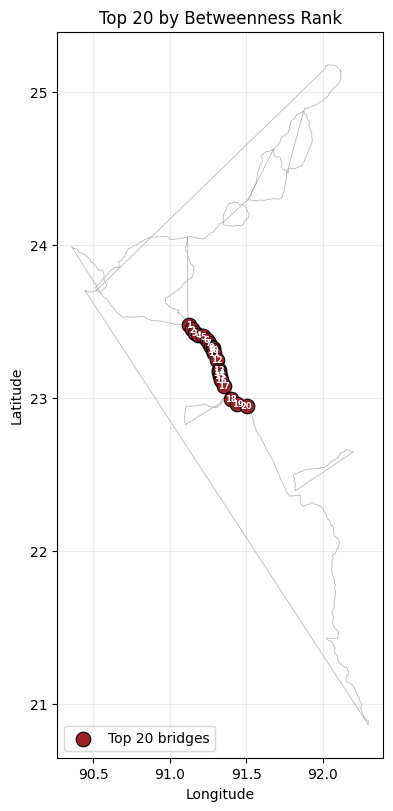

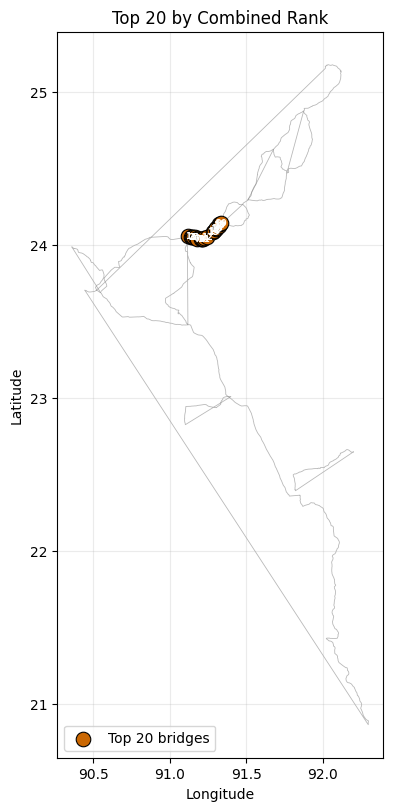

In [29]:
top_n = 20

top_traffic = get_top_n(bridge_geo, 'rank_by_traffic', top_n)
top_between = get_top_n(bridge_geo, 'rank_by_betweenness', top_n)
top_combined = get_top_n(bridge_geo, 'rank_by_combined', top_n)

plots = [
    ('Top 20 by Traffic Rank', top_traffic, 'rank_by_traffic', '#006d77', '../img/top20_traffic_map.png'),
    ('Top 20 by Betweenness Rank', top_between, 'rank_by_betweenness', '#9b2226', '../img/top20_betweenness_map.png'),
    ('Top 20 by Combined Rank', top_combined, 'rank_by_combined', '#ca6702', '../img/top20_combined_map.png'),
]

for title, top_df, rank_col, color, out_path in plots:
    fig, ax = plt.subplots(figsize=(10, 8), constrained_layout=True)
    draw_base_network(ax, df)

    # Show only the selected top-ranked bridge points on top of the road lines.
    ax.scatter(
        top_df['lon'],
        top_df['lat'],
        s=110,
        color=color,
        edgecolor='black',
        linewidth=0.8,
        marker='o',
        label=f'Top {top_n} bridges',
        zorder=8
    )

    for _, row in top_df.iterrows():
        ax.text(
            row['lon'],
            row['lat'],
            str(int(row[rank_col])),
            fontsize=6,
            ha='center',
            va='center',
            color='white',
            fontweight='bold',
            zorder=9
        )

    ax.set_title(title)
    ax.legend(loc='lower left', frameon=True)
    plt.show()

    # Optional save per figure
    # fig_path = Path(out_path)
    # fig.savefig(fig_path, dpi=300, bbox_inches='tight')
    # print('Saved:', fig_path)

In [30]:
# Optional: export figure
# fig_path = Path('../img/bridge_rankings_map_top10.png')
# plt.savefig(fig_path, dpi=300, bbox_inches='tight')
# print('Saved:', fig_path)